# Import Libraries

In [23]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

# Load DataSet

In [24]:
df=pd.read_csv("knn_student_result_large_dataset.csv")
df.head()

,Age,Study_Hours,Attendance,Result
0,24,3.0,53.8,Fail
1,21,1.9,60.6,Fail
2,30,5.7,60.5,Pass
3,28,8.6,75.3,Pass
4,25,1.6,40.0,Fail


# Check dataset

In [25]:
df.shape

(500, 4)

# Basic Information

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          500 non-null    int64  
 1   Study_Hours  500 non-null    float64
 2   Attendance   500 non-null    float64
 3   Result       500 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 15.8+ KB


# Statistical Summary

In [27]:
df.describe()

,Age,Study_Hours,Attendance
count,500.000000,500.000000,500.000000
mean,23.900000,6.545600,73.145600
std,3.774984,3.118321,15.403438
min,18.000000,1.000000,40.000000
25%,21.000000,3.800000,61.250000
50%,24.000000,6.800000,74.100000
75%,27.000000,9.100000,85.500000
max,30.000000,12.000000,100.000000


# Check Missing Values

In [28]:
df.isnull().sum()

Age            0
Study_Hours    0
Attendance     0
Result         0
dtype: int64

# Check Pass/Fail Distribution

In [29]:
df["Result"].value_counts()

Result
Pass    292
Fail    208
Name: count, dtype: int64

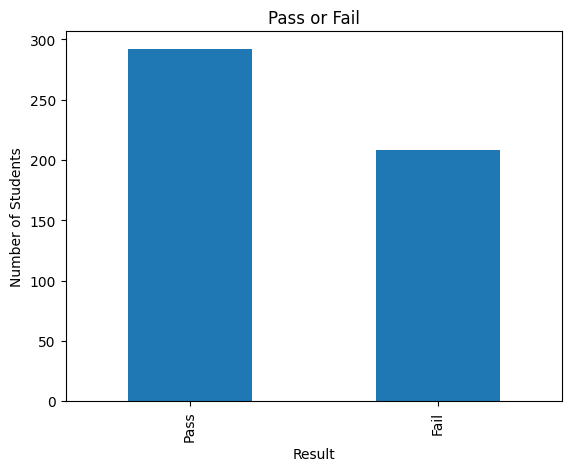

In [30]:
df["Result"].value_counts().plot(kind="bar")

plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.title("Pass or Fail")
plt.show()

# Separate X and Y

In [31]:
X= df[["Age","Study_Hours","Attendance"]]
Y=df["Result"]

# Split into training and testing data

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [33]:
print("Training Data : ",X_train.shape)
print("Testing Data : ",X_test.shape)

Training Data :  (400, 3)
Testing Data :  (100, 3)


# Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Import KNN

In [35]:
from sklearn.neighbors import KNeighborsClassifier

#Create a KNN Classifier with 5 neighbour
knn= KNeighborsClassifier(n_neighbors=5)

# Train the model

In [36]:
knn.fit(X_train_scaled, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Make Prediction

In [37]:
Y_pred= knn.predict(X_test_scaled)
Y_pred[:10]

array(['Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Fail',
       'Pass', 'Pass'], dtype=object)

# Compare actual and predicted

In [38]:
comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": Y_pred
})
comparison.head(20)

,Actual,Predicted
0,Fail,Fail
1,Pass,Pass
2,Pass,Pass
3,Fail,Pass
4,Pass,Pass
5,Pass,Pass
6,Pass,Pass
7,Fail,Fail
8,Pass,Pass
9,Pass,Pass


# Calculate accuracy

In [39]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(Y_test,Y_pred)

print("Accuracy:",accuracy)
print("Accuracy percentage:",accuracy *100,"%")


Accuracy: 0.9
Accuracy percentage: 90.0 %


# Confusion Matrix

In [40]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_pred)
print(cm)

[[40  7]
 [ 3 50]]


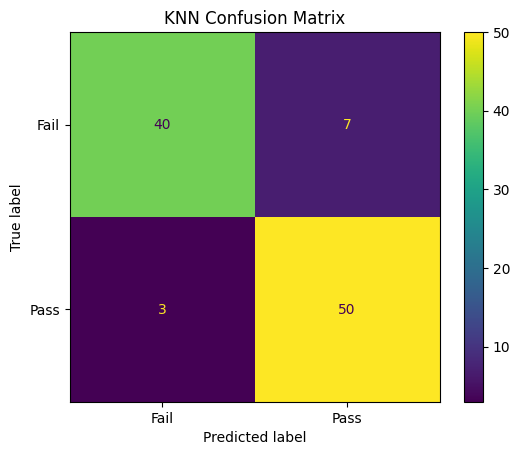

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)
plt.title("KNN Confusion Matrix")
plt.show()

# Classification Report

In [42]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

        Fail       0.93      0.85      0.89        47
        Pass       0.88      0.94      0.91        53

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



# Test Different K values

In [43]:
k_values = range(1,21)

accuracies=[]
for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled,Y_train)
    Y_pred=knn.predict(X_test_scaled)
    accuracy=accuracy_score(Y_test,Y_pred)
    accuracies.append(accuracy)
 

In [44]:
best_k=k_values[np.argmax(accuracies)]
best_accuracy= max(accuracies)

print("Best K:",best_k)
print("Best Accuracy:",best_accuracy)

Best K: 16
Best Accuracy: 0.92


# Visualize K Vs Accuracy

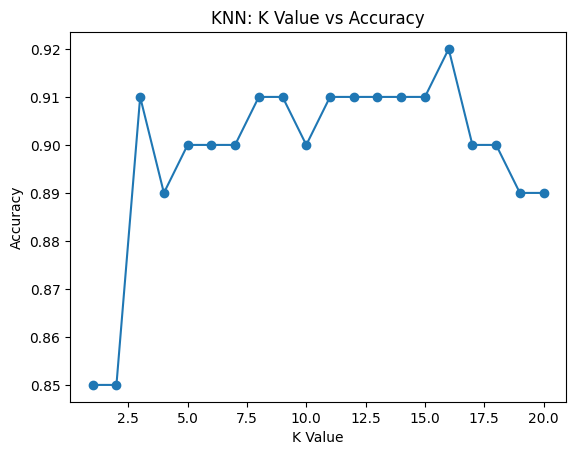

In [45]:
plt.plot(k_values,accuracies,marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")

plt.show()

# Train final model with best K

In [46]:
best_knn= KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled,Y_train)

,n_neighbors,16
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
final_predictions = best_knn.predict(X_test_scaled)
final_accuracy = accuracy_score(Y_test,final_predictions)
print("Final Accuracy;",final_accuracy)

Final Accuracy; 0.92


# Predict a completely new Student

In [48]:
new_student=pd.DataFrame({
    "Age":[23],
    "Study_Hours":[8],
    "Attendance":[85]
})
new_student

,Age,Study_Hours,Attendance
0,23,8,85


In [49]:
#Scale it
new_student_scaled = scaler.transform(new_student)

In [50]:
#predict
prediction = best_knn.predict(new_student_scaled)
print("Prediction Result:",prediction[0])

Prediction Result: Pass


# Model Deployment

In [51]:
#save the model and scaler for future use
import joblib
joblib.dump(best_knn,"knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# test loading model

In [1]:
import joblib
model= joblib.load("knn_model.pkl")
scaler= joblib.load("scaler.pkl")

# Create a prediction function

In [2]:
def predict_result(age,study_hours,attendance):
    new_student= [(age,study_hours,attendance)]
    new_student_scaled=scaler.transform(new_student)
    prediction=model.predict(new_student_scaled)
    return prediction[0]

In [3]:
result = predict_result(23,8,85)
print(result)

Pass


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
